# Healthcare Utilization, Cost & Demand Analytics Platform

## Exploratory Data Analysis (EDA)

This notebook explores patient demographics, healthcare utilization patterns, medical conditions, healthcare costs, provider utilization, and organization performance.

The objective is to answer key business questions and identify insights that can support healthcare decision-making.

## Business Questions

This exploratory analysis aims to answer the following questions:

1. Who are the patients utilizing healthcare services?
2. How are healthcare services being utilized?
3. What are the most common medical conditions?
4. What factors drive healthcare costs?
5. How are healthcare organizations and providers utilized?
6. What healthcare demand trends exist within the dataset?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

patients = pd.read_csv("patients_clean.csv")
encounters = pd.read_csv("encounters_clean.csv")
conditions = pd.read_csv("conditions_clean.csv")
providers = pd.read_csv("providers_clean.csv")
organizations = pd.read_csv("organizations_clean.csv")

# 1. Patient Demographics Analysis

Understanding patient demographics helps healthcare organizations identify population segments that may require targeted services and resource allocation.

## Age Group Distribution

This analysis examines the distribution of patients across different age groups to understand the demographic profile of the patient population.

In [3]:
age_dist = (patients['age_group'].value_counts().sort_index())

age_dist

age_group
0-17     185
18-34    256
35-49    191
50-64    249
65+      282
Name: count, dtype: int64

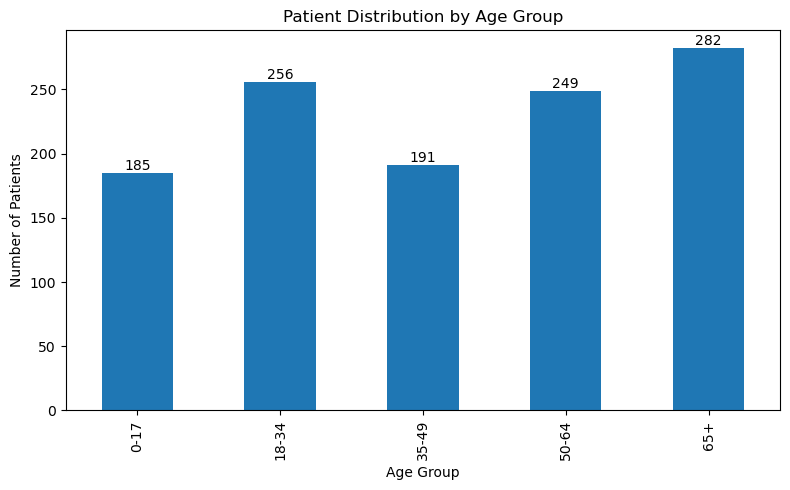

In [4]:
ax = age_dist.plot(kind='bar',figsize=(8,5))
plt.title('Patient Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Patients')
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.tight_layout()
plt.show()

### Business Insight

Patients aged 65+ represent the largest age group in the dataset, followed by patients aged 18–34 and 50–64. This indicates that older adults account for a significant portion of the patient population and are likely to drive healthcare utilization and spending.

The age distribution suggests that healthcare organizations should prioritize services and resource planning for middle-aged and senior populations.

## Gender Distribution

This analysis evaluates the gender composition of the patient population.

In [5]:
gender_dist = patients['gender'].value_counts()

gender_dist

gender
F    616
M    547
Name: count, dtype: int64

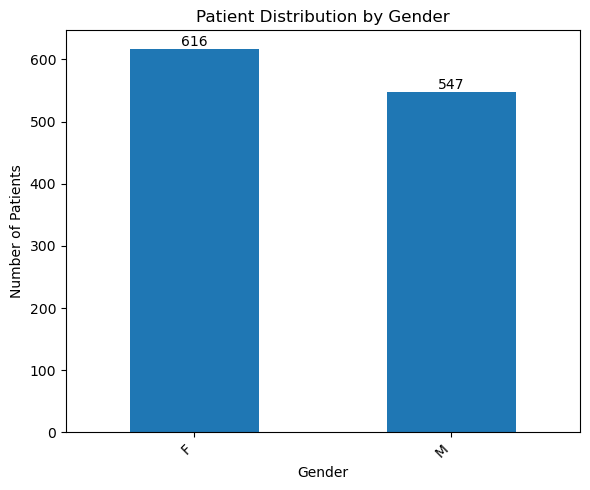

In [6]:
ax = gender_dist.plot(kind='bar',figsize=(6,5))
plt.title('Patient Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45,ha='right')
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.tight_layout()
plt.show()

### Business Insight

The patient population is relatively balanced across genders, with females slightly outnumbering males. This indicates that healthcare utilization is not heavily concentrated within a single gender group.

A balanced gender distribution allows subsequent analyses to focus on utilization and cost differences rather than population imbalance.

## Race Distribution

This analysis examines racial representation within the patient population.

In [7]:
race_dist = patients['race'].value_counts()

race_dist

race
white       963
black        96
asian        73
hawaiian     18
other        11
native        2
Name: count, dtype: int64

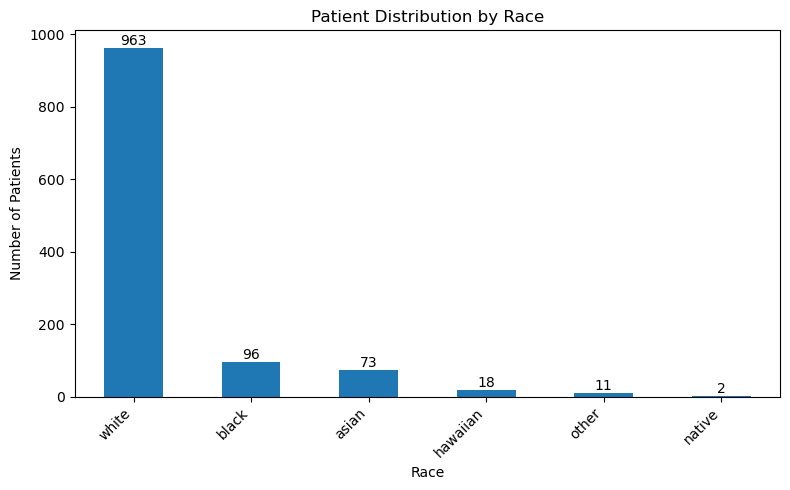

In [8]:
ax = race_dist.plot(kind='bar',figsize=(8,5))
plt.title('Patient Distribution by Race')
plt.xlabel('Race')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45,ha='right')
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.tight_layout()
plt.show()

### Business Insight

The patient population is predominantly White, accounting for the vast majority of records in the dataset. Other racial groups represent a much smaller share of the population.

Because of this imbalance, race-based comparisons should be interpreted cautiously, as smaller groups may not contain enough observations for reliable conclusions.

# 2. Healthcare Utilization Analysis

Healthcare utilization analysis examines how patients interact with healthcare services and identifies the most frequently used service categories.

## Encounter Type Distribution

This analysis evaluates the distribution of healthcare encounters across different encounter categories.

In [9]:
encounter_types = (encounters['encounter_type'].value_counts())

encounter_types

encounter_type
wellness      24038
ambulatory    20124
outpatient    10837
urgentcare     2564
emergency      2168
inpatient      1728
Name: count, dtype: int64

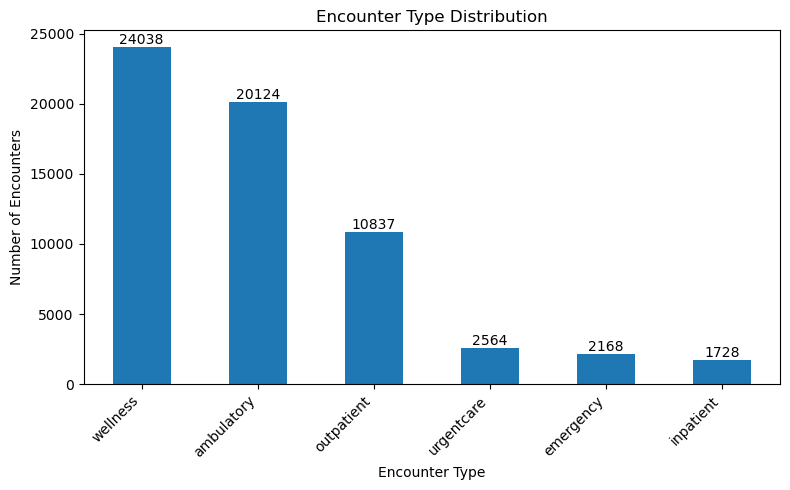

In [10]:
ax = encounter_types.plot(kind='bar',figsize=(8,5))
plt.title('Encounter Type Distribution')
plt.xlabel('Encounter Type')
plt.ylabel('Number of Encounters')
plt.xticks(rotation=45,ha='right')
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.tight_layout()
plt.show()

### Business Insight

Wellness and ambulatory encounters account for the majority of healthcare utilization, indicating that most patient interactions involve routine care, preventive services, and non-emergency visits.

Emergency and inpatient encounters represent a relatively small proportion of total encounters, suggesting that healthcare demand is primarily driven by outpatient and preventive care services.

## Healthcare Demand Trend

This analysis examines how healthcare encounters have changed over time and helps identify long-term utilization trends.

In [11]:
yearly_encounters = (encounters.groupby('year').size())

yearly_encounters=yearly_encounters.tail(30)

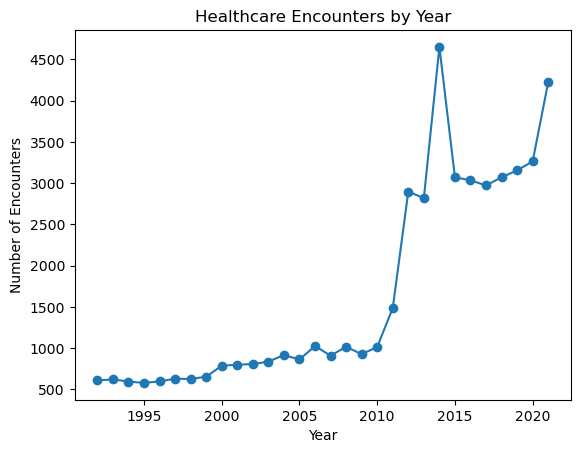

In [12]:
yearly_encounters.plot(kind='line',marker='o')
plt.title('Healthcare Encounters by Year')
plt.xlabel('Year')
plt.ylabel('Number of Encounters')
plt.show()

### Business Insight

Healthcare encounter volume shows a strong upward trend over time, particularly after 2010. This growth suggests increasing healthcare utilization and demand across the patient population.

The sustained increase in encounters highlights the importance of resource planning, staffing, and capacity management. The upward trend also supports the use of forecasting techniques to estimate future healthcare demand.

## Encounters Per Patient

This analysis examines how frequently patients interact with healthcare services.

Understanding encounter frequency helps identify utilization patterns and determine whether healthcare demand is concentrated among a subset of patients.

In [13]:
encounters_per_patient = (encounters.groupby('patient_id').size())
encounters_per_patient.describe()

count    1163.000000
mean       52.845228
std        72.628805
min         2.000000
25%        21.000000
50%        40.000000
75%        64.000000
max      1563.000000
dtype: float64

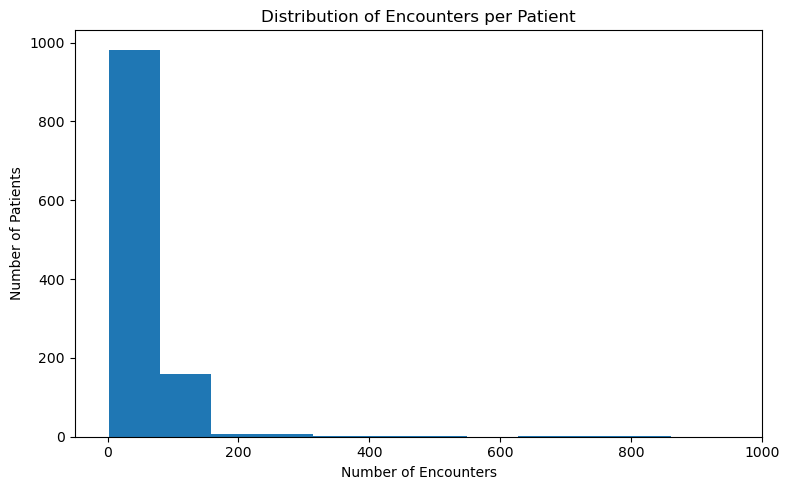

In [14]:
plt.figure(figsize=(8,5))
plt.hist(encounters_per_patient,bins=20)
plt.title('Distribution of Encounters per Patient')
plt.xlabel('Number of Encounters')
plt.ylabel('Number of Patients')
plt.xlim(-50,1000)
plt.tight_layout()
plt.show()

### Business Insight

Healthcare utilization is highly concentrated among a subset of patients. While the median patient records 40 encounters, a small number of patients exhibit exceptionally high encounter volumes, with the highest-utilization patient exceeding 1,500 encounters.

This pattern suggests that a relatively small patient population may account for a disproportionate share of healthcare resource consumption.

## High Utilization Patients

This analysis identifies patients with the highest number of healthcare encounters.

High-utilization patients often account for a disproportionate share of healthcare resource consumption.

In [15]:
top_patients = (encounters.groupby('patient_id').size().sort_values(ascending=False).head(10))

top_patients.index = [f'Patient {i}' for i in range(1, 11)]

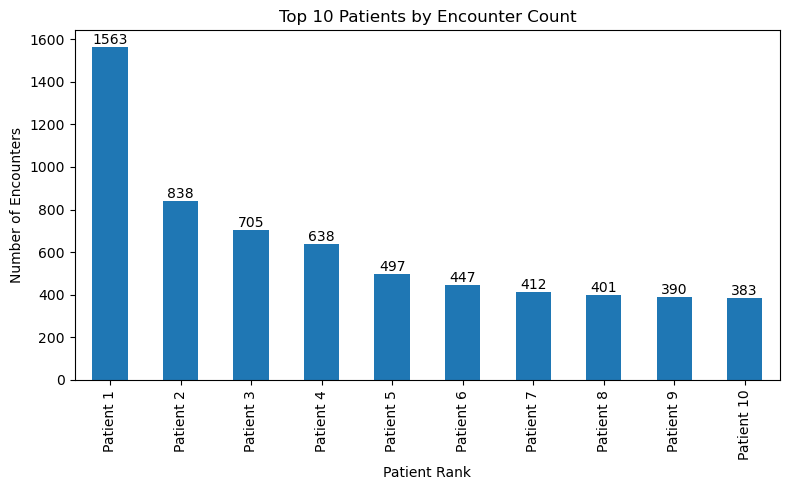

In [16]:
ax = top_patients.plot(kind='bar',figsize=(8,5))

plt.title('Top 10 Patients by Encounter Count')
plt.xlabel('Patient Rank')
plt.ylabel('Number of Encounters')
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

### Business Insight

Healthcare utilization is highly concentrated among a small subset of patients. The highest-utilization patient recorded 1,563 encounters, nearly twice as many as the second-ranked patient and substantially more than the remaining top-utilization patients.

This pattern suggests that a relatively small group of patients may account for a disproportionate share of healthcare resource consumption. Identifying and monitoring these high-utilization patients can help healthcare organizations improve care management, optimize resource allocation, and potentially reduce avoidable healthcare costs.

## Monthly Healthcare Utilization

This analysis evaluates encounter volume across calendar months to identify seasonal utilization patterns.

In [17]:
monthly_encounters = (encounters.groupby('month_name').size())

monthly_encounters

month_name
April        5202
August       4921
December     5038
February     5935
January      5102
July         4963
June         4884
March        5598
May          5192
November     4919
October      4987
September    4718
dtype: int64

In [18]:
month_order = [
    'January','February','March',
    'April','May','June',
    'July','August','September',
    'October','November','December'
]

monthly_encounters = (encounters.groupby('month_name').size().reindex(month_order))

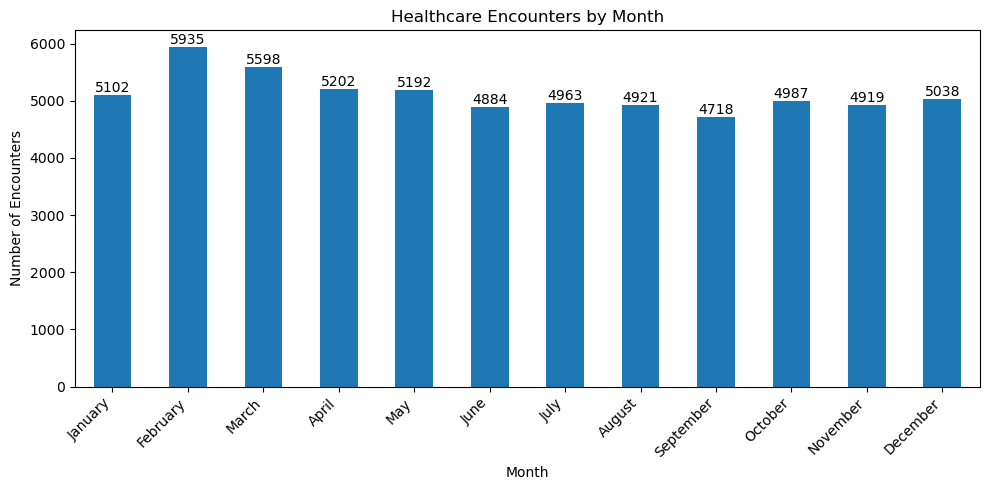

In [19]:
ax = monthly_encounters.plot(kind='bar',figsize=(10,5))
plt.title('Healthcare Encounters by Month')
plt.xlabel('Month')
plt.ylabel('Number of Encounters')
plt.xticks(rotation=45,ha='right')
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

### Business Insight

Healthcare encounter volume remains relatively stable throughout the year, with only modest variation between months.

The absence of strong seasonal patterns suggests that healthcare demand is consistently distributed across the calendar year, reducing the risk of major seasonal capacity constraints.

## Encounters by Day of Week

This analysis identifies which days experience the highest healthcare demand.

In [20]:
day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

daily_encounters = (encounters.groupby('day_of_week').size().reindex(day_order))

daily_encounters

day_of_week
Monday        8729
Tuesday      10953
Wednesday     8012
Thursday      7689
Friday        8971
Saturday      9051
Sunday        8054
dtype: int64

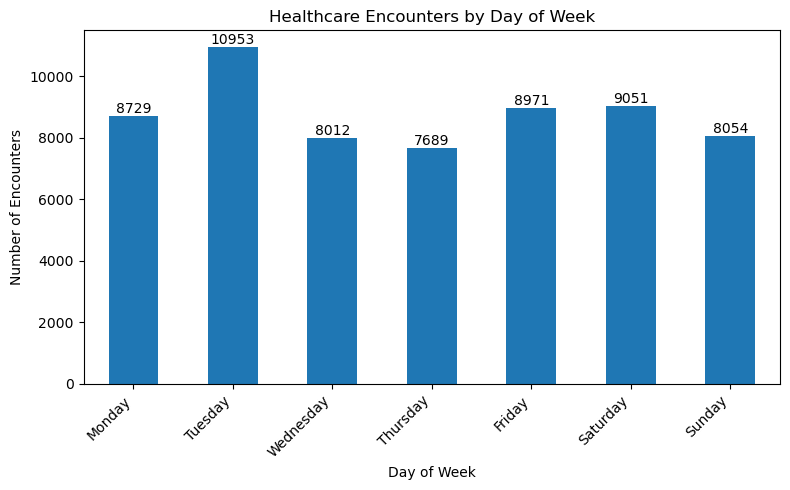

In [21]:
ax = daily_encounters.plot(kind='bar',figsize=(8,5))

plt.title('Healthcare Encounters by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Encounters')
plt.xticks(rotation=45,ha='right')
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

### Business Insight

Healthcare encounters occur throughout the week, with Tuesday recording the highest encounter volume. Weekend encounter activity remains substantial, indicating continuous healthcare utilization across all days of the week.

This pattern reflects consistent healthcare demand rather than concentration within traditional business days.

## Weekday vs Weekend Utilization

This analysis compares healthcare demand between weekdays and weekends.

In [22]:
weekday_weekend = (encounters['weekday_weekend'].value_counts())

weekday_weekend

weekday_weekend
Weekday    44354
Weekend    17105
Name: count, dtype: int64

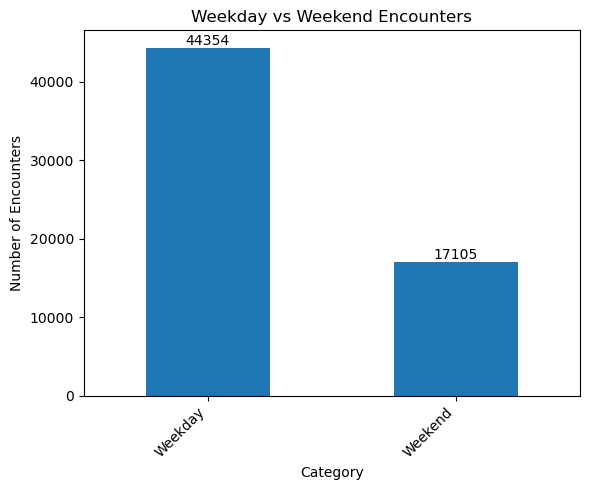

In [23]:
ax = weekday_weekend.plot(kind='bar',figsize=(6,5))

plt.title('Weekday vs Weekend Encounters')
plt.xlabel('Category')
plt.xticks(rotation=45,ha='right')
plt.ylabel('Number of Encounters')

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

### Business Insight

Although healthcare utilization occurs throughout the week, approximately 72% of encounters take place on weekdays.

This distribution aligns with typical healthcare operations, where routine and preventive services are primarily delivered during standard business days.

# 3. Condition Analysis

Understanding common medical conditions helps healthcare organizations identify population health trends, prioritize interventions, and allocate healthcare resources effectively.

In [24]:
top_conditions = (conditions['condition_name'].value_counts().head(20))

top_conditions

condition_name
Full-time employment (finding)                               13805
Stress (finding)                                              5137
Part-time employment (finding)                                2426
Social isolation (finding)                                    1243
Viral sinusitis (disorder)                                    1233
Limited social contact (finding)                              1200
Not in labor force (finding)                                  1077
Victim of intimate partner abuse (finding)                     819
Acute viral pharyngitis (disorder)                             678
Acute bronchitis (disorder)                                    571
Reports of violence in the environment (finding)               565
Normal pregnancy                                               527
Received higher education (finding)                            523
Body mass index 30+ - obesity (finding)                        463
Risk activity involvement (finding)            

### Business Insight

Social and behavioral factors such as employment status, stress, social isolation, and education appear frequently throughout patient records. These factors may influence healthcare utilization patterns and provide important context for population health management initiatives.

In [25]:
medical_conditions = conditions[
    conditions['condition_name'].str.contains(
        r'\(disorder\)|pregnancy|Prediabetes|Hypertension',
        case=False,
        na=False
    )
]

top_medical_conditions = (medical_conditions['condition_name'].value_counts().head(15))
top_medical_conditions = top_medical_conditions[top_medical_conditions.index != 'Normal pregnancy']

top_medical_conditions

condition_name
Viral sinusitis (disorder)              1233
Acute viral pharyngitis (disorder)       678
Acute bronchitis (disorder)              571
Prediabetes                              341
Anemia (disorder)                        324
Hypertension                             292
Chronic sinusitis (disorder)             219
Streptococcal sore throat (disorder)     162
Acute bacterial sinusitis (disorder)      74
Hypertriglyceridemia (disorder)           71
Metabolic syndrome X (disorder)           68
Osteoporosis (disorder)                   58
Sinusitis (disorder)                      54
Hyperglycemia (disorder)                  41
Name: count, dtype: int64

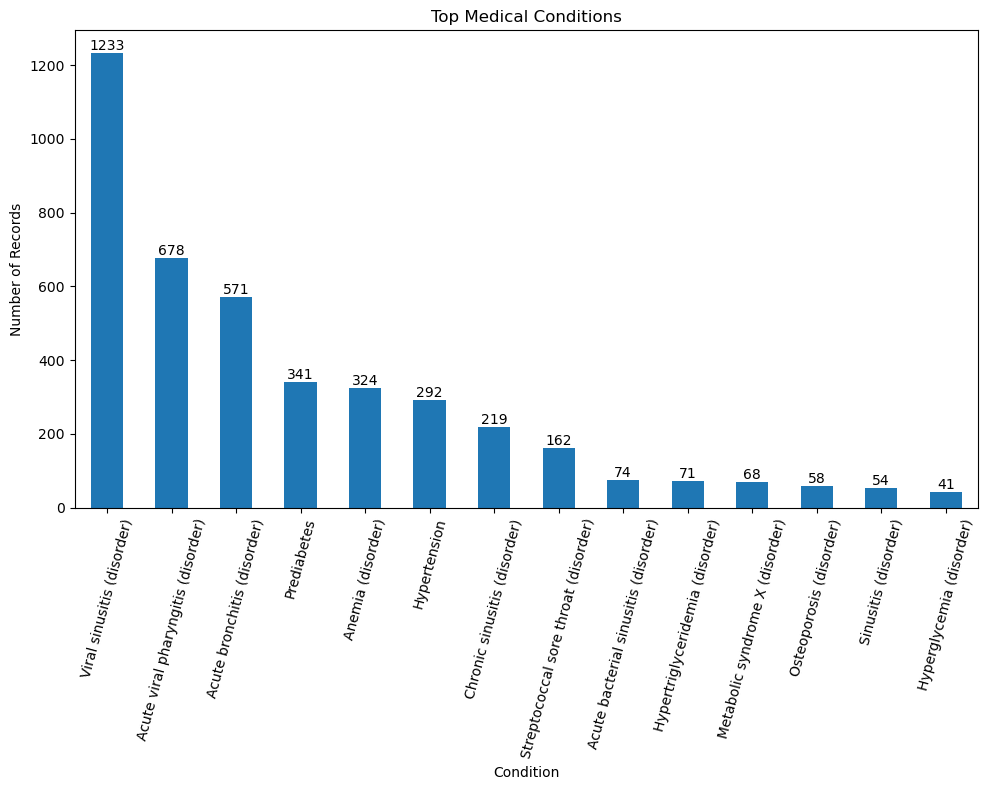

In [26]:
ax = top_medical_conditions.plot(kind='bar',figsize=(10,8))
plt.title('Top Medical Conditions')
plt.xlabel('Condition')
plt.ylabel('Number of Records')

plt.xticks(rotation=75)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

### Business Insight

Respiratory-related conditions dominate the patient population, with Viral Sinusitis, Acute Viral Pharyngitis, and Acute Bronchitis representing the most frequently recorded medical conditions.

Several chronic conditions, including Prediabetes, Hypertension, Anemia, and Hypertriglyceridemia, also appear prominently within the dataset. The presence of these long-term conditions highlights the importance of preventive care, chronic disease management, and early intervention strategies.

Overall, the condition profile suggests that healthcare demand is driven by a combination of common acute respiratory illnesses and chronic metabolic and cardiovascular risk factors.

## Condition Status Analysis

This analysis evaluates the proportion of active and resolved conditions within the patient population.

Understanding condition status helps assess the burden of ongoing healthcare needs and chronic disease management requirements.

In [27]:
condition_status = (conditions['condition_status'].value_counts())

condition_status

condition_status
Resolved    29925
Active       8169
Name: count, dtype: int64

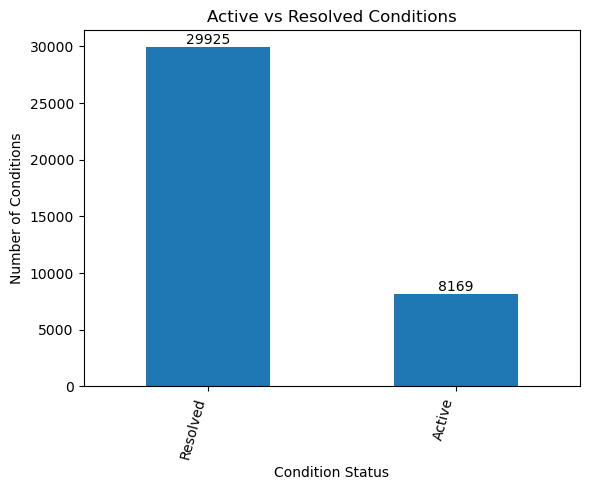

In [28]:
ax = condition_status.plot(kind='bar',figsize=(6,5))

plt.title('Active vs Resolved Conditions')
plt.xlabel('Condition Status')
plt.ylabel('Number of Conditions')
plt.xticks(rotation=75,ha='right')

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

### Business Insight

Approximately 79% of recorded conditions are classified as resolved, while 21% remain active. This indicates that most healthcare conditions documented in the dataset were successfully treated or no longer required ongoing management.

However, the presence of more than 8,000 active conditions highlights a substantial ongoing healthcare burden and suggests continued demand for chronic disease management, monitoring, and follow-up care.

The active condition population may represent patients who require long-term healthcare services and contribute disproportionately to future healthcare utilization.

# 4. Healthcare Cost Analysis

Healthcare cost analysis examines spending patterns across the patient population and identifies the major drivers of healthcare expenditures.

Understanding cost drivers helps healthcare organizations improve financial planning, resource allocation, and cost management initiatives.

## Healthcare Expenses Distribution

This analysis examines the distribution of healthcare expenses across patients and identifies whether healthcare spending is concentrated among a subset of individuals.

In [29]:
patients['total_healthcare_expenses'].describe()

count    1.163000e+03
mean     1.256248e+06
std      1.148747e+06
min      8.259920e+02
25%      4.426256e+05
50%      1.142154e+06
75%      1.900910e+06
max      2.311655e+07
Name: total_healthcare_expenses, dtype: float64

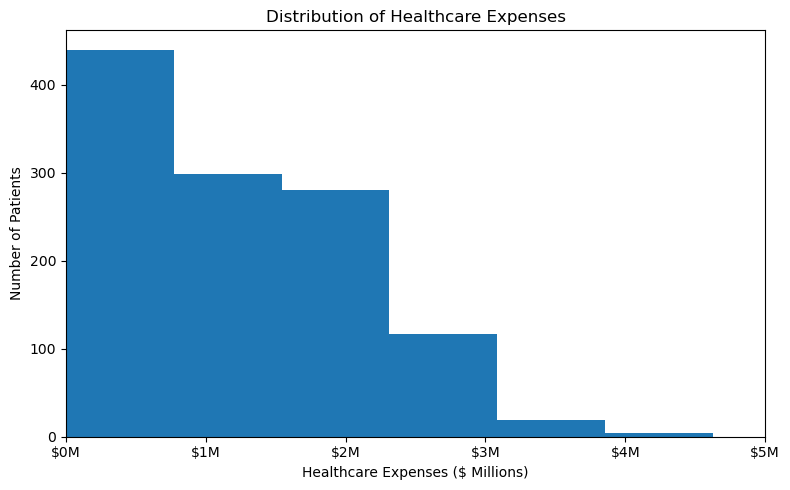

In [39]:
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(8,5))
plt.hist(patients['total_healthcare_expenses'],bins=30)
plt.title('Distribution of Healthcare Expenses')
plt.xlabel('Healthcare Expenses ($ Millions)')
plt.ylabel('Number of Patients')
plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'${x/1e6:.0f}M')
)
plt.xlim(0, 5_000_000)

plt.tight_layout()
plt.show()

### Business Insight

Healthcare expenses are highly concentrated among a relatively small subset of patients. While the median patient incurred approximately $1.14 million in healthcare expenses, a small number of patients generated exceptionally high costs, with the highest recorded expense exceeding $23 million.

This right-skewed distribution indicates that healthcare spending is not evenly distributed across the patient population. A limited number of high-cost patients may account for a disproportionate share of total healthcare expenditures.

Understanding the characteristics and healthcare utilization patterns of these high-cost patients can help healthcare organizations improve cost management, care coordination, and resource allocation strategies.

## Healthcare Expense Outliers

A boxplot is used to further investigate the presence of extreme healthcare expenses and identify potential outlier patients that contribute disproportionately to total healthcare spending.

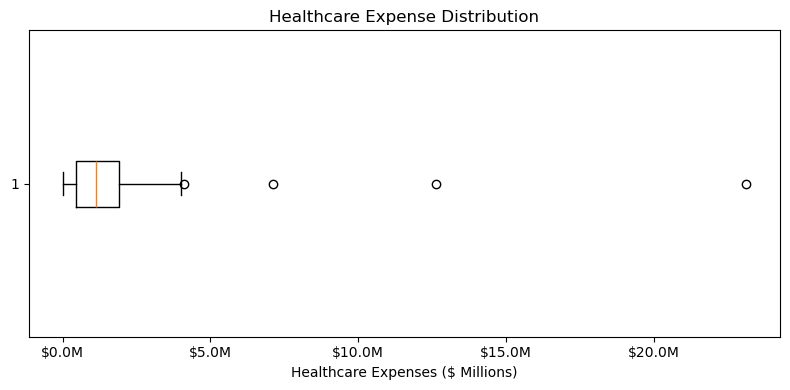

In [36]:
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(8,4))

plt.boxplot(
    patients['total_healthcare_expenses'],
    vert=False
)

plt.title('Healthcare Expense Distribution')
plt.xlabel('Healthcare Expenses ($ Millions)')

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'${x/1e6:.1f}M')
)

plt.tight_layout()
plt.show()

### Business Insight

The boxplot reveals a highly skewed healthcare expense distribution with several extreme outliers. While most patients fall within a relatively concentrated expense range, a small number of patients incur substantially higher healthcare costs.

These high-cost patients may represent individuals with chronic conditions, complex treatment requirements, or frequent healthcare utilization. Their disproportionate contribution to total healthcare spending highlights the importance of targeted care management and cost-control strategies.

## Total Claim Cost by Encounter Type

This analysis evaluates total healthcare spending across different encounter types.

Understanding which healthcare services generate the highest costs helps identify major cost drivers and supports financial planning, resource allocation, and operational decision-making.

In [32]:
cost_by_type = (encounters.groupby('encounter_type')['total_claim_cost'].sum().sort_values(ascending=False))

cost_by_type

encounter_type
ambulatory    1.312929e+08
wellness      4.590036e+07
outpatient    3.064173e+07
emergency     1.718445e+07
inpatient     1.514765e+07
urgentcare    1.486678e+07
Name: total_claim_cost, dtype: float64

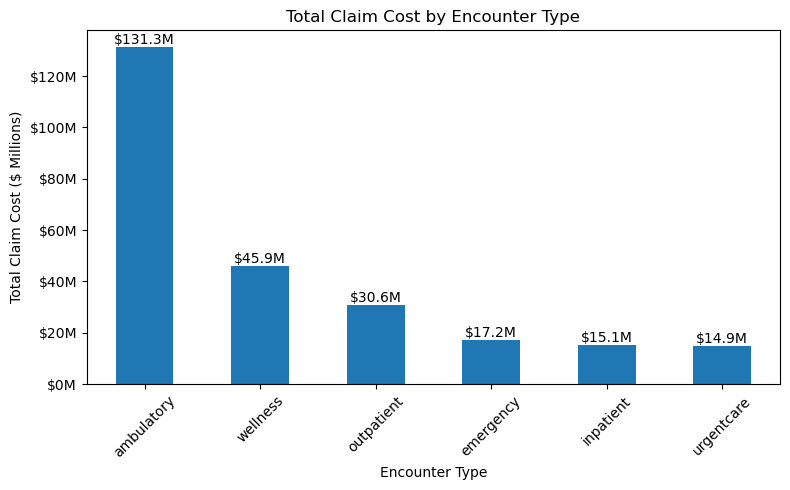

In [35]:
from matplotlib.ticker import FuncFormatter

ax = cost_by_type.plot(kind='bar',figsize=(8,5))

plt.title('Total Claim Cost by Encounter Type')
plt.xlabel('Encounter Type')
plt.ylabel('Total Claim Cost ($ Millions)')

plt.xticks(rotation=45)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${x/1e6:.0f}M'))

for p in ax.patches:
    ax.annotate(
        f'${p.get_height()/1e6:.1f}M',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

### Business Insight

Ambulatory encounters account for the largest share of total healthcare spending, generating more than $131 million in total claim costs. Despite wellness encounters being the most frequent encounter type, ambulatory services contribute substantially higher overall costs.

Outpatient, emergency, inpatient, and urgent care encounters generate significantly lower total costs compared to ambulatory services, indicating that a large portion of healthcare expenditures is concentrated within routine and follow-up care settings.

These findings suggest that cost optimization efforts should focus on ambulatory and outpatient services, as improvements within these categories are likely to have the greatest financial impact.

## Healthcare Cost by Age Group

This analysis evaluates healthcare spending across different age groups to identify which patient segments contribute most to overall healthcare costs.

Understanding age-based spending patterns helps healthcare organizations allocate resources effectively and develop targeted care management strategies.

In [40]:
cost_by_age = (encounters.merge(patients[['patient_id', 'age_group']],on='patient_id')
    .groupby('age_group')['total_claim_cost']
    .sum()
    .reindex([
        '0-17',
        '18-34',
        '35-49',
        '50-64',
        '65+'
    ])
)
cost_by_age

age_group
0-17      3817334.89
18-34    55206229.47
35-49    48071165.61
50-64    50948573.17
65+      96990524.94
Name: total_claim_cost, dtype: float64

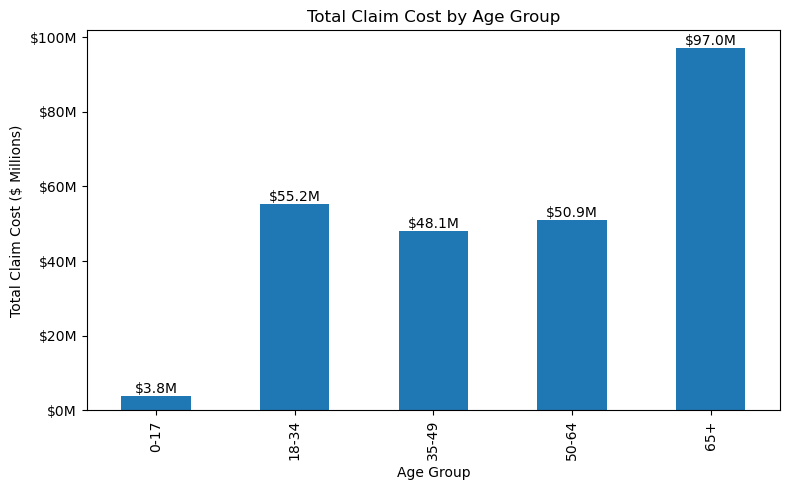

In [41]:
from matplotlib.ticker import FuncFormatter

ax = cost_by_age.plot(kind='bar',figsize=(8,5))
plt.title('Total Claim Cost by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Claim Cost ($ Millions)')
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'${x/1e6:.0f}M')
)

for p in ax.patches:
    ax.annotate(
        f'${p.get_height()/1e6:.1f}M',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

### Business Insight

Patients aged 65 and older account for the highest total healthcare spending, generating approximately $97 million in total claim costs. This spending level is nearly double that of any other age group.

The findings indicate that senior patients represent the largest financial burden on the healthcare system, likely due to increased healthcare utilization, chronic disease prevalence, and ongoing medical care requirements.

As populations age, healthcare organizations may need to allocate additional resources toward geriatric care, chronic disease management, and preventive health programs to effectively manage future demand and costs.

## Average Claim Cost by Age Group

While total healthcare spending identifies the age groups contributing the most overall costs, average claim cost highlights which age groups incur the highest cost per healthcare encounter.

This analysis helps distinguish between high utilization and high-cost care.

In [43]:
avg_cost_by_age = (encounters.merge(patients[['patient_id', 'age_group']],on='patient_id')
    .groupby('age_group')['total_claim_cost']
    .mean()
)
avg_cost_by_age

age_group
0-17     1121.426231
18-34    6032.808378
35-49    5945.722401
50-64    3570.077302
65+      3653.402326
Name: total_claim_cost, dtype: float64

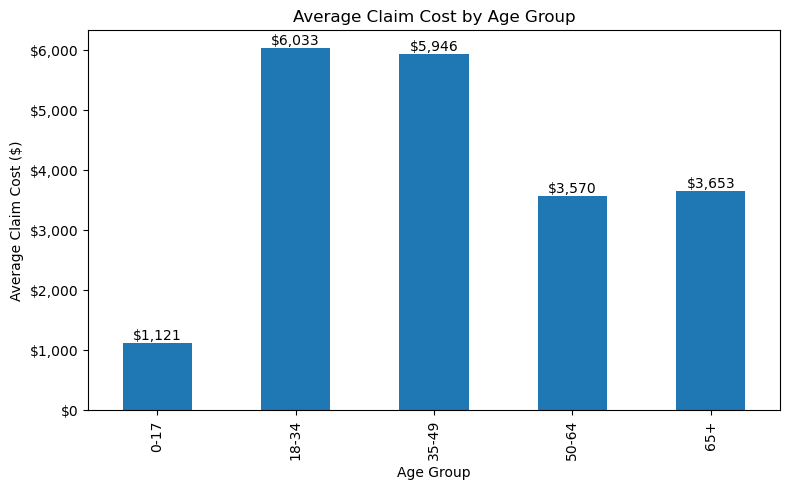

In [44]:
from matplotlib.ticker import FuncFormatter

ax = avg_cost_by_age.plot(kind='bar',figsize=(8,5))

plt.title('Average Claim Cost by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Claim Cost ($)')

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'${x:,.0f}')
)

for p in ax.patches:
    ax.annotate(
        f'${p.get_height():,.0f}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

### Business Insight

Patients aged 18–34 and 35–49 exhibit the highest average claim costs per encounter, exceeding $5,900 per claim on average.

Although patients aged 65 and older generate the highest total healthcare spending, younger adult populations appear to incur more expensive individual encounters. This suggests that total healthcare spending is driven by both encounter frequency and encounter cost, emphasizing the importance of evaluating healthcare expenditures from multiple perspectives.

## Insurance Coverage vs Out-of-Pocket Costs

Healthcare expenses are typically shared between insurance providers and patients.

This analysis compares total payer coverage and total out-of-pocket costs to understand how healthcare expenditures are distributed across the healthcare financing system.

In [45]:
payment_breakdown = pd.Series({
    'Insurance Coverage': encounters['payer_coverage'].sum(),
    'Out-of-Pocket': encounters['out_of_pocket_cost'].sum()
})

payment_breakdown

Insurance Coverage    6.353076e+07
Out-of-Pocket         1.915031e+08
dtype: float64

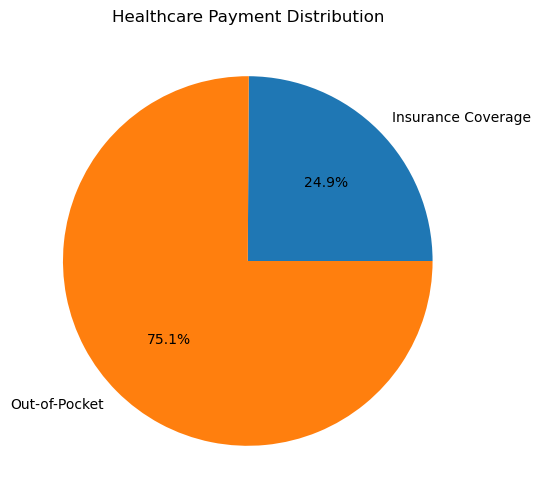

In [48]:
plt.figure(figsize=(6,6))

plt.pie(
    payment_breakdown,
    labels=payment_breakdown.index,
    autopct='%1.1f%%'
)

plt.title('Healthcare Payment Distribution')
plt.show()

### Business Insight

Out-of-pocket payments account for approximately 75% of total healthcare spending, while insurance coverage contributes about 25%.

This distribution indicates that a significant portion of healthcare costs is borne directly by patients within the dataset. Such a cost structure may increase the financial burden on patients and could potentially influence healthcare utilization patterns and access to care.

The findings highlight the importance of monitoring patient cost exposure and evaluating opportunities to improve financial accessibility through insurance coverage and cost-management initiatives.

# 5. Organization Analysis

Healthcare organizations vary in terms of utilization, patient volume, and financial performance.

This section evaluates organization-level activity to identify the facilities that contribute most significantly to healthcare service delivery.

## Top Organizations by Utilization

This analysis identifies the healthcare organizations with the highest utilization levels.

Understanding utilization patterns helps healthcare administrators evaluate facility demand and resource allocation requirements.

In [49]:
top_org_utilization = (organizations.nlargest(10,'organization_utilization'))

top_org_utilization[['organization_name','organization_utilization']]

,organization_name,organization_utilization
16,NORTH SHORE MEDICAL CENTER -,3954
24,LOWELL GENERAL HOSPITAL,3852
52,LAHEY HOSPITAL & MEDICAL CENTER BURLINGTON,3409
50,FALMOUTH HOSPITAL,3111
1,MOUNT AUBURN HOSPITAL,2877
4,CAMBRIDGE HEALTH ALLIANCE,2706
29,MORTON HOSPITAL,2673
22,BETH ISRAEL DEACONESS HOSPITAL - PLYMOUTH,2595
43,WINCHESTER HOSPITAL,2555
42,NEWTON-WELLESLEY HOSPITAL,2380


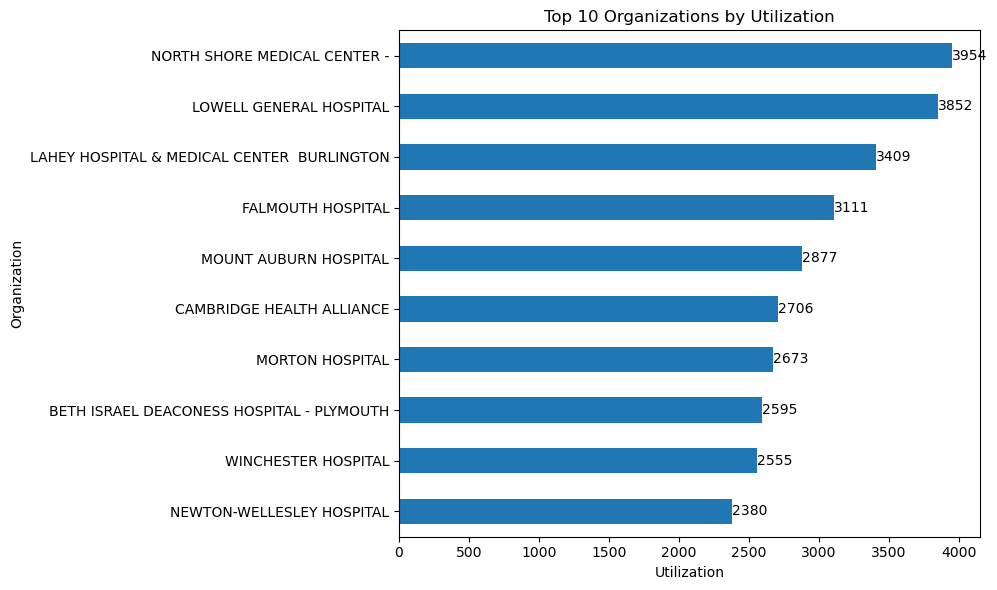

In [ ]:
ax = (top_org_utilization.sort_values('organization_utilization').plot(
        x='organization_name',
        y='organization_utilization',
        kind='barh',
        figsize=(10,6),
        legend=False
    )
)

plt.title('Top 10 Organizations by Utilization')
plt.xlabel('Utilization')
plt.ylabel('Organization')
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()

### Business Insight

Healthcare utilization is concentrated among a relatively small number of organizations. North Shore Medical Center recorded the highest utilization, with nearly 4,000 service interactions, followed closely by Lowell General Hospital and Lahey Hospital & Medical Center.

The top-performing organizations consistently handle substantially higher patient volumes than other facilities, indicating that healthcare demand is not evenly distributed across the healthcare network.

These findings can help healthcare administrators identify high-demand facilities, prioritize resource allocation, and support capacity planning initiatives.

# 6. Provider Analysis

Healthcare providers play a critical role in delivering patient care and managing healthcare demand.

This section evaluates provider specialties and utilization patterns to better understand workforce distribution and provider workload across the healthcare network.

## Provider Specialty Distribution

This analysis examines the distribution of healthcare providers across different medical specialties.

Understanding specialty representation helps identify workforce composition and areas of clinical expertise within the healthcare system.

In [70]:
top_specialties = (
    providers['specialty']
    .value_counts()
    .head(10)
)

top_specialties

specialty
GENERAL PRACTICE          1128
PHYSICIAN ASSISTANT        542
NURSE PRACTITIONER         387
CLINICAL SOCIAL WORKER     376
PHYSICAL THERAPY           344
INTERNAL MEDICINE          312
FAMILY PRACTICE            259
CHIROPRACTIC               153
OPTOMETRY                  151
CLINICAL PSYCHOLOGIST      139
Name: count, dtype: int64

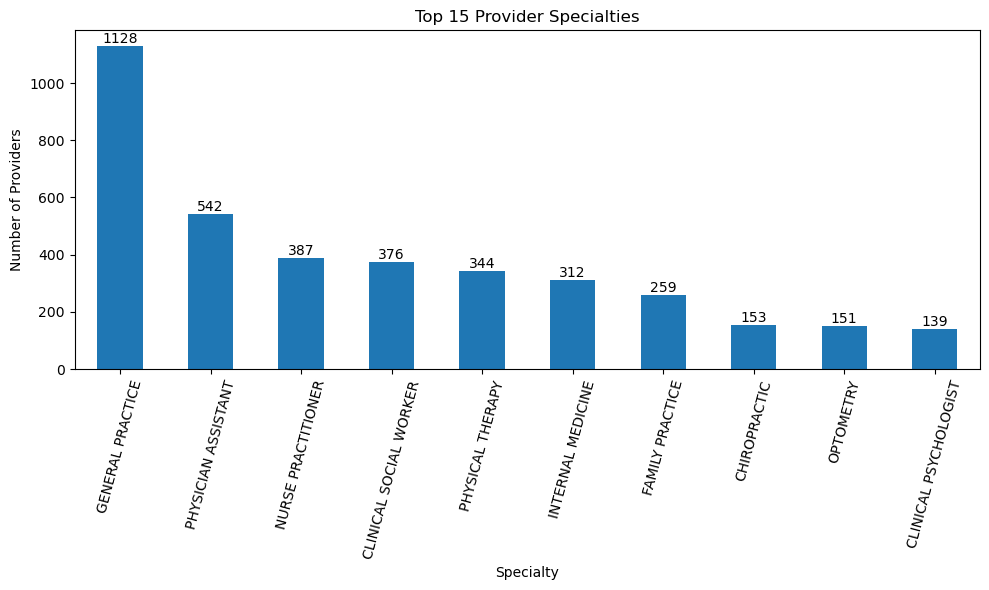

In [73]:
ax = top_specialties.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Top 15 Provider Specialties')
plt.xlabel('Specialty')
plt.ylabel('Number of Providers')

plt.xticks(rotation=75)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

### Business Insight

General Practice represents the largest provider specialty within the healthcare network, accounting for more than 1,100 providers. Physician Assistants, Nurse Practitioners, Clinical Social Workers, and Physical Therapists also represent significant portions of the healthcare workforce.

The specialty distribution suggests a strong emphasis on primary care and preventive healthcare services, supported by a multidisciplinary care model that includes nursing, behavioral health, and rehabilitation professionals.

## Provider Utilization Distribution

This analysis evaluates provider utilization levels to understand how healthcare workload is distributed across the provider network.

In [79]:
providers['provider_utilization'].describe(
    percentiles=[0.90,0.95,0.99]
)

count    5056.000000
mean       28.670095
std       187.393116
min         0.000000
50%         0.000000
90%        47.000000
95%        73.000000
99%       568.450000
max      3954.000000
Name: provider_utilization, dtype: float64

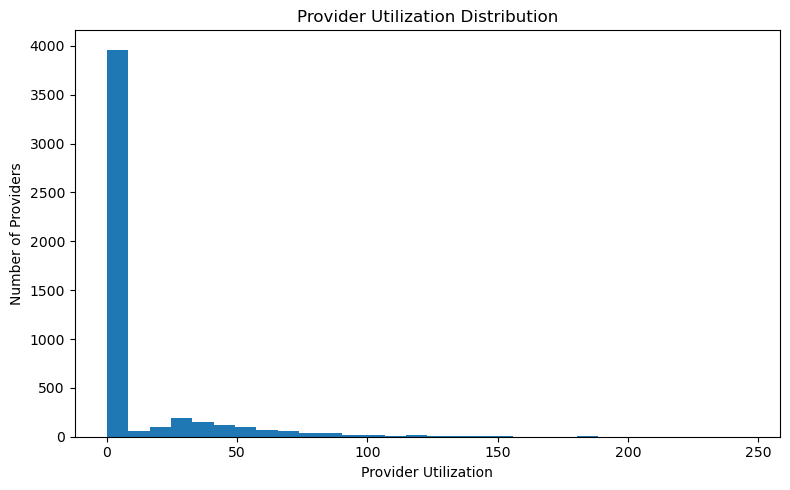

In [80]:
plt.figure(figsize=(8,5))

plt.hist(
    providers[
        providers['provider_utilization'] < 250
    ]['provider_utilization'],
    bins=30
)

plt.title('Provider Utilization Distribution')
plt.xlabel('Provider Utilization')
plt.ylabel('Number of Providers')

plt.tight_layout()
plt.show()

### Business Insight

Provider utilization is highly uneven across the healthcare network. Most providers operate within a relatively low-to-moderate utilization range, while a small number of providers experience exceptionally high utilization levels.

This pattern suggests that healthcare demand is concentrated among a subset of providers, potentially creating workload imbalances and opportunities for improved resource allocation.

# 7. Exploratory Data Analysis Summary

The exploratory analysis examined patient demographics, healthcare utilization patterns, medical conditions, healthcare costs, organizational activity, and provider characteristics.

Several important patterns emerged regarding healthcare demand, spending, and service delivery across the healthcare system.

## Key Findings

- Patients aged 65 and older represent the largest patient segment and account for the highest total healthcare spending.
- Healthcare utilization is dominated by wellness and ambulatory encounters.
- Respiratory illnesses and chronic conditions are among the most frequently recorded medical conditions.
- Approximately 79% of recorded conditions have been resolved, while 21% remain active.
- Healthcare costs are highly concentrated among a small number of patients, with several extreme spending outliers.
- Ambulatory encounters generate the highest total claim costs across encounter types.
- Healthcare demand is concentrated among a relatively small number of healthcare organizations.
- General Practice providers represent the largest specialty group within the healthcare workforce.

## Business Recommendations

- Expand preventive care and chronic disease management programs for older patient populations.
- Monitor high-cost patients to identify opportunities for care coordination and cost reduction.
- Prioritize operational improvements within ambulatory care settings, which represent the largest source of healthcare spending.
- Allocate resources strategically to high-utilization healthcare organizations to support growing patient demand.
- Strengthen primary care capacity to ensure continued access to healthcare services and improve patient outcomes.